In [54]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


C:\Users\VICTUS 16\AppData\Local\Temp\ipykernel_19384\3555863535.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(["Not Survived", "Survived"])


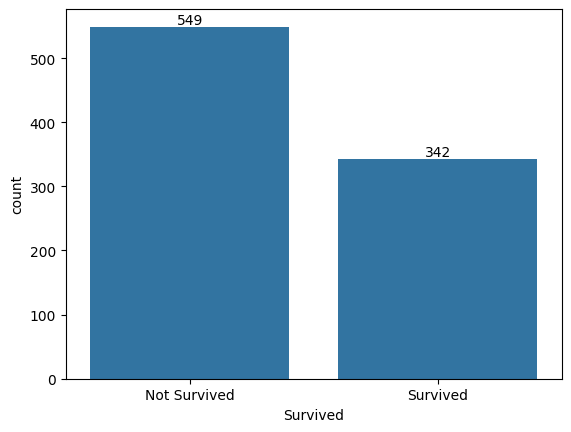

In [55]:
# =========================================
# 1. Data Overview
# =========================================
train_df = pd.read_csv("../data/train.csv")
test_df = pd.read_csv("../data/test.csv")
train_df.info()
train_df.describe()
train_df["Survived"].value_counts()
ax = sns.countplot(data=train_df, x="Survived")
ax.set_xticklabels(["Not Survived", "Survived"])

for container in ax.containers:
    ax.bar_label(container)

plt.show()

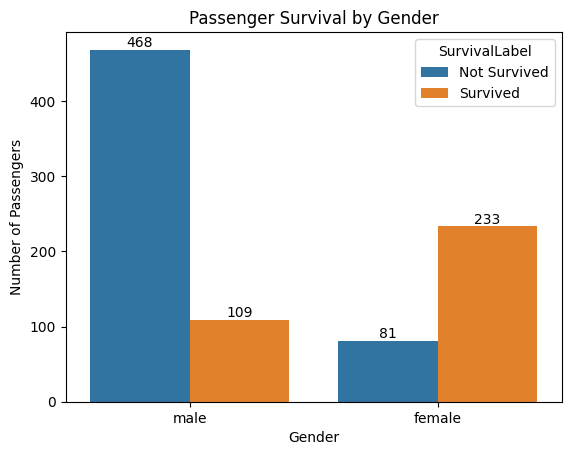

In [56]:
# =========================================
# 2. Gender Analysis
# =========================================
# Visualize the number of passengers by gender,
# separated by survival status
train_df["SurvivalLabel"] = train_df["Survived"].map({
    0: "Not Survived",
    1: "Survived"
})
ax = sns.countplot(
    data=train_df,
    x="Sex",
    hue="SurvivalLabel"
)

# Display the exact count on top of each bar
for container in ax.containers:
    ax.bar_label(container)

plt.title("Passenger Survival by Gender")
plt.xlabel("Gender")
plt.ylabel("Number of Passengers")

plt.show()

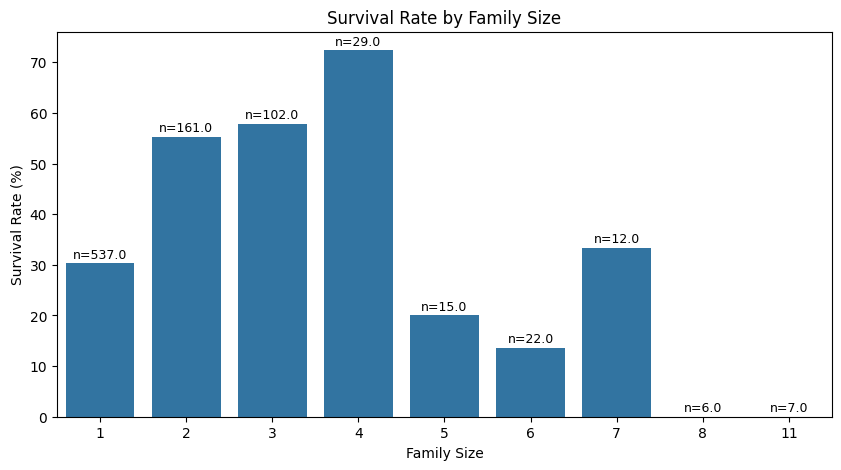

In [57]:
# =========================================
# 3. Family Analysis
# =========================================

# Calculate survival rate and sample size for each family size group
train_df["FamilySize"] = train_df["SibSp"] + train_df["Parch"] + 1
family_stats = (
    train_df.groupby("FamilySize")
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate to percentage
family_stats["SurvivalRate"] *= 100

# Create visualization
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=family_stats,
    x="FamilySize",
    y="SurvivalRate"
)

# Add sample size annotations on top of bars
for i, row in family_stats.iterrows():
    ax.text(
        i,
        row["SurvivalRate"] + 1,
        f'n={row["Count"]}',
        ha='center',
        fontsize=9
    )

plt.title("Survival Rate by Family Size")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

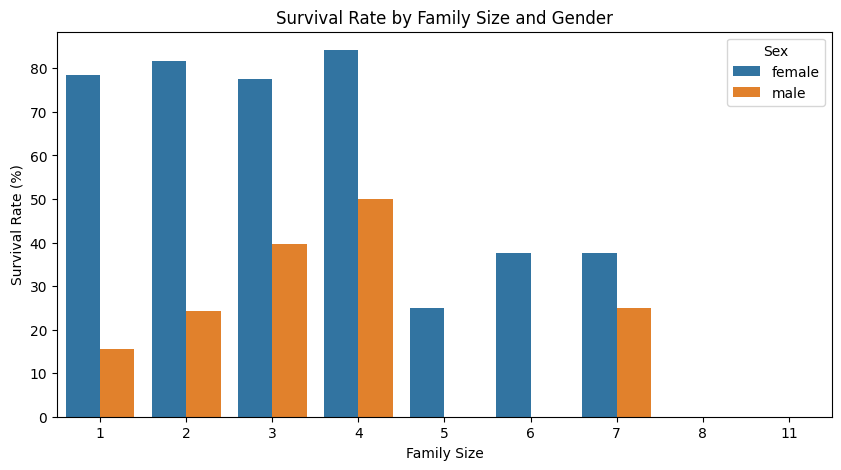

,FamilySize,Sex,SurvivalRate,Count
0,1,female,78.571429,126
1,1,male,15.571776,411
2,2,female,81.609195,87
3,2,male,24.324324,74
4,3,female,77.551020,49
5,3,male,39.622642,53
6,4,female,84.210526,19
7,4,male,50.000000,10
8,5,female,25.000000,12
9,5,male,0.000000,3


In [58]:
# =========================================
# 3. Family & Gender Analysis
# =========================================

# Calculate survival rate and sample size for each group
survival_gender_family = (
    train_df.groupby(["FamilySize", "Sex"])
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate to percentage
survival_gender_family["SurvivalRate"] *= 100

# Create visualization
plt.figure(figsize=(10, 5))

ax = sns.barplot(
    data=survival_gender_family,
    x="FamilySize",
    y="SurvivalRate",
    hue="Sex"
)

# Add labels
plt.title("Survival Rate by Family Size and Gender")
plt.xlabel("Family Size")
plt.ylabel("Survival Rate (%)")

plt.show()

# Group data by FamilySize and Sex to compute:
# - Survival rate (mean of Survived)
# - Number of passengers in each group
group_stats = (
    train_df.groupby(["FamilySize", "Sex"])
    .agg(
        SurvivalRate=("Survived", "mean"),
        Count=("Survived", "count")
    )
    .reset_index()
)

# Convert survival rate from ratio (0–1) to percentage (0–100)
group_stats["SurvivalRate"] *= 100

# Sort groups by family size (most reliable groups first)
group_stats = group_stats.sort_values(
    "FamilySize"
)

# Display result
group_stats